# EDA and data cleaning

In [1]:
%load_ext autoreload
%autoreload 2
import sys
import os

# 1. Get the directory of the current notebook
notebook_dir = os.path.abspath('')

# 2. Go up two levels to reach the 'src' root directory
src_root = os.path.abspath(os.path.join(notebook_dir, '..'))

# 3. Target the 'utils' folder exactly
utils_path = os.path.join(src_root, 'utils')

# 4. Append to sys.path if it's not already there
if utils_path not in sys.path:
    sys.path.append(utils_path)

#  FORCE CACHE CLEAR: Manually evict the old module version from Python's memory
if 'eda_and_data_cleaning_master_model' in sys.modules:
    del sys.modules['eda_and_data_cleaning_master_model']

print(f"Added to path: {utils_path}")

# 5. Import your functions seamlessly
from eda_and_data_cleaning_master_model import (
    summarize_dataset_structure, 
    drop_missing_landmark_frames, 
    plot_feature_variance_by_class, 
    plot_feature_collinearity_matrix, 
    plot_signal_stability_over_time
)

Added to path: d:\YogAi_Models_Refactor\src\utils


In [2]:

raw_master_df = summarize_dataset_structure("../../data/processed/engineered_features/master_pose/master_pose_features.csv")


       RESEARCH COMPREHENSIVE PROFILE: ../../data/processed/engineered_features/master_pose/master_pose_features.csv               
 DATASET DIMENSIONS:
   - Total Recorded Frames (Rows): 38532
   - Total Columns: 18
   - Biomechanical Features Detected (14): ['left_elbow_angle', 'right_elbow_angle', 'left_knee_angle', 'right_knee_angle', 'left_hip_angle', 'right_hip_angle', 'stance_width_normalized', 'wrist_span_normalized', 'torso_incline_angle', 'leg_incline_angle', 'left_arm_elevation', 'right_arm_elevation', 'left_hip_line_deviation', 'right_hip_line_deviation']

 FEATURE DESCRIPTIVE STATISTICS (ANGLES/DISTANCES):


,mean,std,min,max
left_elbow_angle,118.903583,36.475128,15.311246,179.487694
right_elbow_angle,118.649745,38.315979,30.284199,179.516031
left_knee_angle,169.182740,10.092167,17.220401,179.722102
right_knee_angle,164.922908,15.138523,19.157828,179.714435
left_hip_angle,142.217590,33.137444,46.206417,179.692379
right_hip_angle,138.601299,32.890340,45.723663,179.688060
stance_width_normalized,1.049614,1.043433,0.040021,111.480780
wrist_span_normalized,1.589011,1.075426,0.111958,14.303614
torso_incline_angle,46.606407,30.140864,0.000011,89.998274
leg_incline_angle,51.183235,32.169317,0.000007,89.999734




 LABEL/CLASS DISTRIBUTION (Target Balance):
   - Class 'plank': 28520 frames (74.02%)
   - Class 'warrior2': 5372 frames (13.94%)
   - Class 'mountain': 4640 frames (12.04%)


📹 VIDEO SOURCE DISTRIBUTION (Data Diversity):
   - Total unique video sources: 359
   - Frames per top sources:
source_id
plank                     28520
arms_not_dropped_1.mp4      225
arms_not_dropped_2.mp4      225
arms_not_dropped_3.mp4      225
arms_not_dropped_4.mp4      225

🔍 LANDMARK DROP/MISSING VALUE PROFILE:
   - Phenomenal! Zero missing values detected in the raw dataset.



In [3]:

# Run Targeted Structural Cleaning
cleaned_master_df = drop_missing_landmark_frames(raw_master_df)


[CLEANING] Dropped 0 frames due to incomplete landmark tracking.
[CLEANING] Remaining stable frames: 38532


In [4]:
# Count before filtering
initial_count = len(cleaned_master_df)

# Apply the outlier filter
cleaned_master_df = cleaned_master_df[cleaned_master_df['stance_width_normalized'] < 5.0]

# Count after filtering
final_count = len(cleaned_master_df)
dropped_count = initial_count - final_count

# Print the breakdown nicely
print(f"--- Stance Width Outlier Removal Summary ---")
print(f"Initial row count: {initial_count}")
print(f"Rows dropped (stance width >= 5.0): {dropped_count}")
print(f"Final cleaned row count: {final_count}")
print(f"--------------------------------------------")

--- Stance Width Outlier Removal Summary ---
Initial row count: 38532
Rows dropped (stance width >= 5.0): 95
Final cleaned row count: 38437
--------------------------------------------


In [5]:
# Drop rows where normalized stance width is unrealistically high (e.g., > 5.0)
cleaned_master_df = cleaned_master_df[cleaned_master_df['stance_width_normalized'] < 5.0]

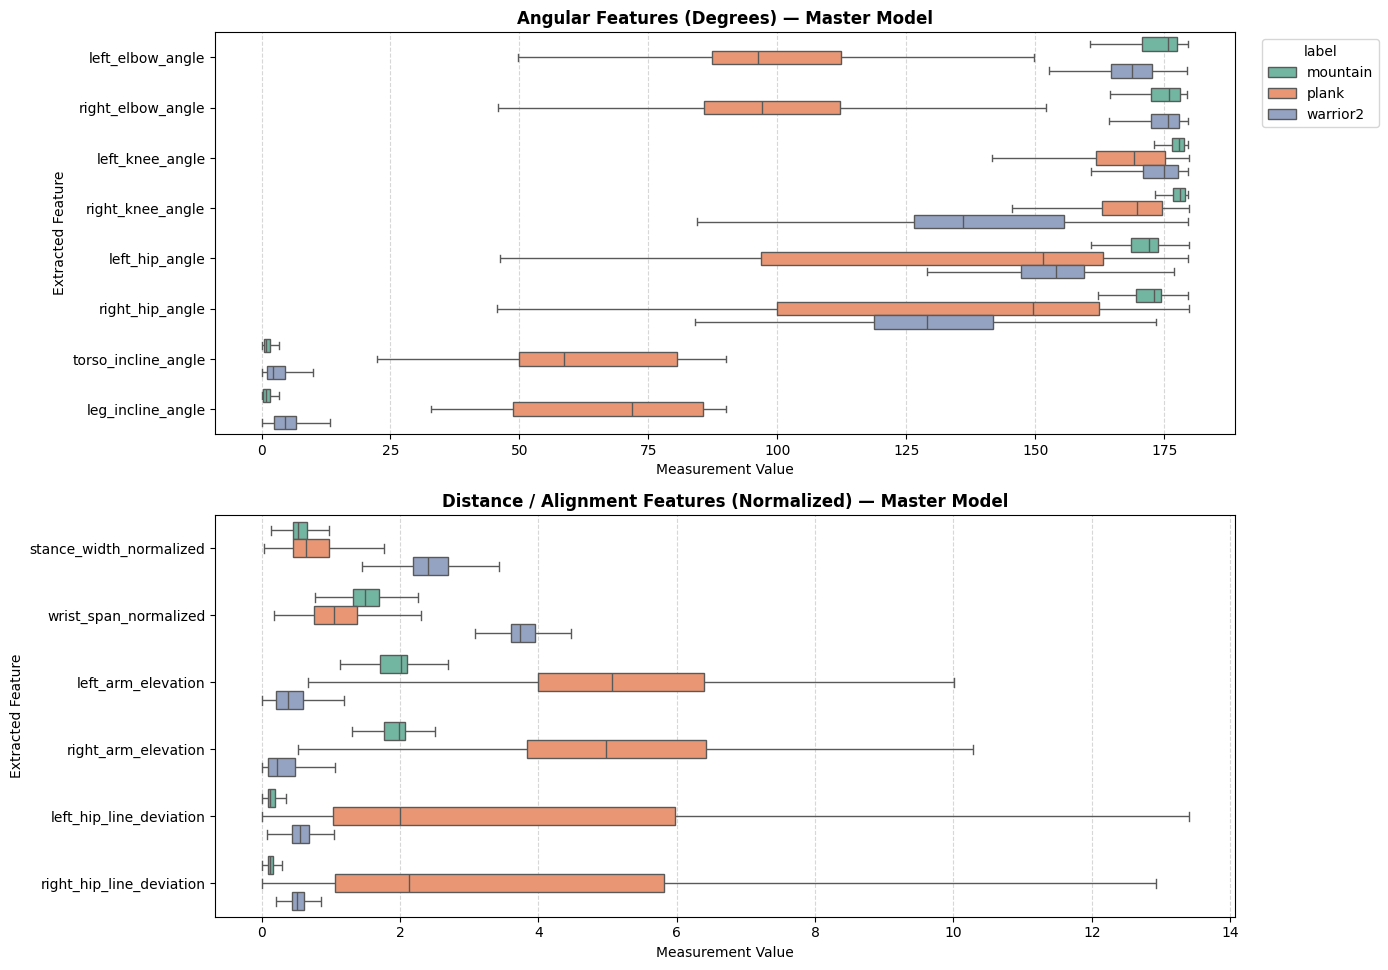

In [6]:

# Visualization
plot_feature_variance_by_class(cleaned_master_df, pose_name="Master Model")


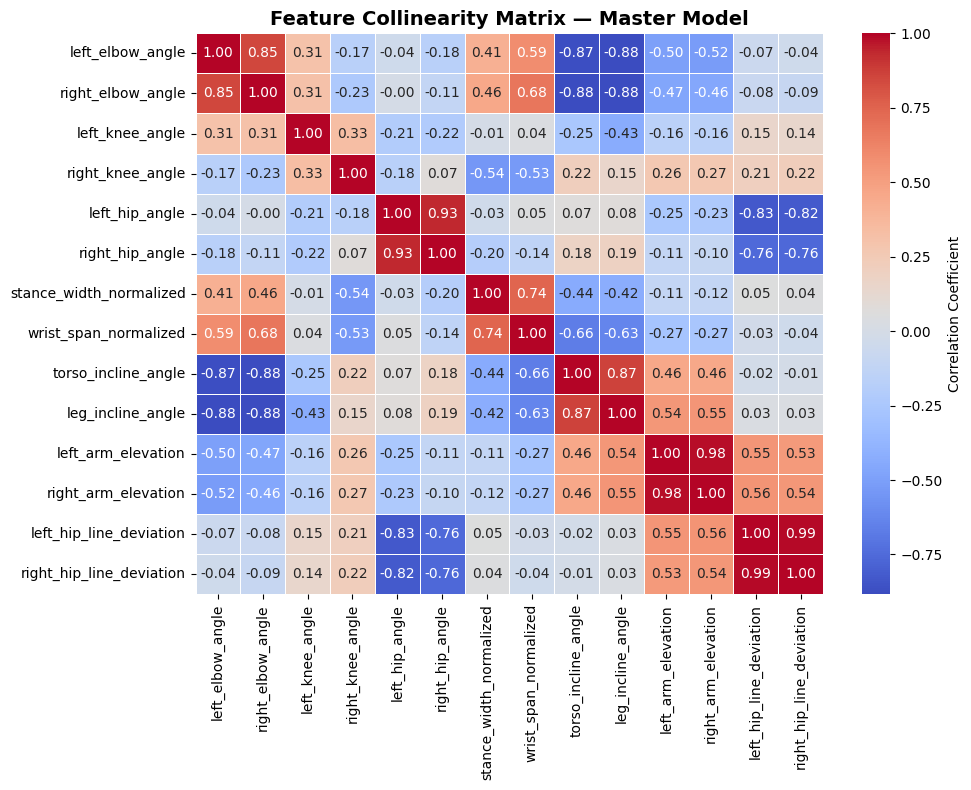

In [7]:
plot_feature_collinearity_matrix(cleaned_master_df, pose_name="Master Model")

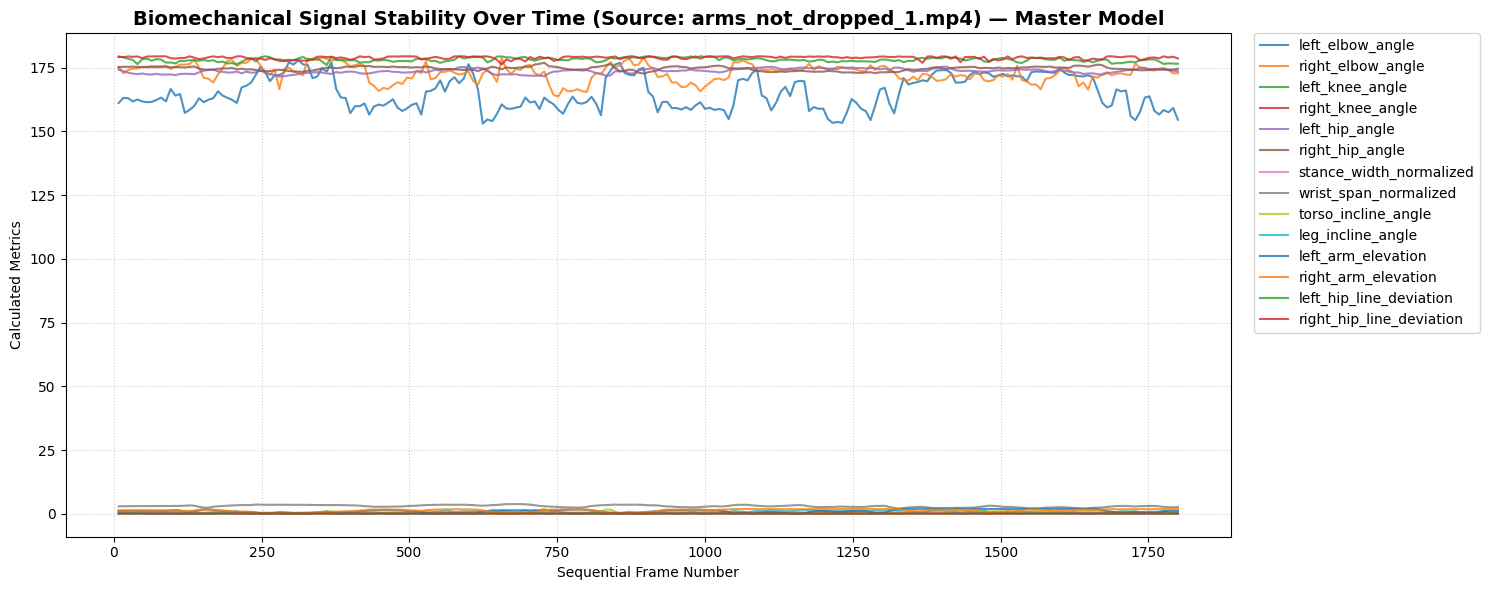

In [8]:
plot_signal_stability_over_time(cleaned_master_df, pose_name="Master Model")
